**INSTALL LIBRARY YANG DIBUTUHKAN**

In [ ]:
!pip install transformers torch nltk scikit-learn pandas numpy seaborn matplotlib tqdm

In [ ]:
# === CELL 1: Import Libraries dan Setup === #
import pandas as pd
import numpy as np
from google.colab import drive
import torch
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, TensorDataset, RandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Mount Google Drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Mounted at /content/drive


**LOAD DATA**

=== Informasi Dataset ===

Informasi kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id                              2000 non-null   int64 
 1   language                        2000 non-null   object
 2   review                          1995 non-null   object
 3   created                         2000 non-null   object
 4   voted_up                        2000 non-null   bool  
 5   votes_up                        2000 non-null   int64 
 6   comment_count                   2000 non-null   int64 
 7   steam_purchase                  2000 non-null   bool  
 8   received_for_free               2000 non-null   bool  
 9   written_during_early_access     2000 non-null   bool  
 10  author.num_games_owned          2000 non-null   int64 
 11  author.num_reviews              2000 non-null   int64 
 12  auth

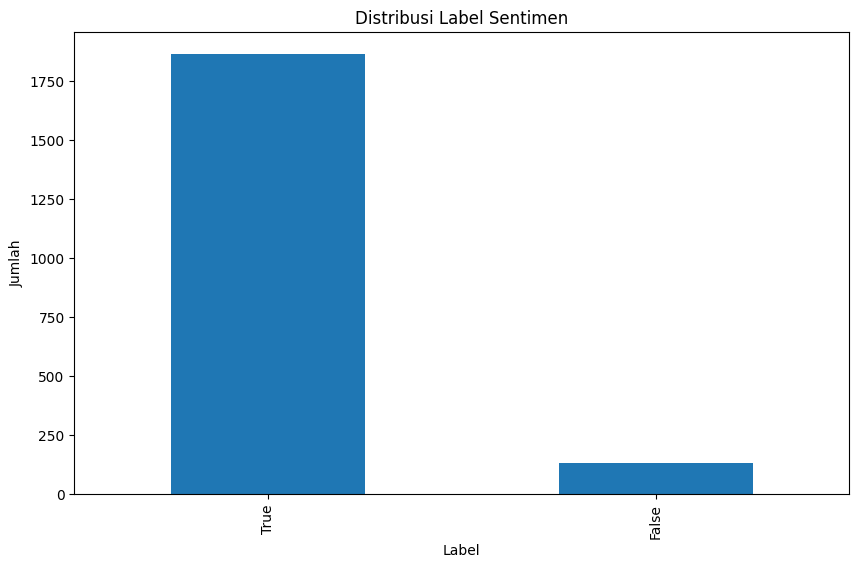

In [ ]:
# === CELL 2: Load dan Eksplorasi Data === #
import re

# Baca dataset
df = pd.read_csv('/content/drive/MyDrive/EldenRIng/data/elden_ring_english_reviews_2024.csv')

# Analisis awal dataset
print("=== Informasi Dataset ===")
print("\nInformasi kolom:")
print(df.info())

print("\nJumlah data awal:", len(df))
print("\nContoh 5 data pertama:")
print(df.head())

print("\nDistribusi label:")
print(df['voted_up'].value_counts())

# Visualisasi distribusi label
plt.figure(figsize=(10, 6))
df['voted_up'].value_counts().plot(kind='bar')
plt.title('Distribusi Label Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.savefig('label_distribution.png')
plt.show()

**Pre-Processing Data**

In [ ]:
import re
import pandas as pd

def clean_text(text):
    if isinstance(text, str):
        # Lowercase
        text = text.lower()
        # Hapus URL
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Hapus HTML tags
        text = re.sub(r'<.*?>', '', text)
        # Hapus karakter khusus dan angka
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\d+', '', text)
        # Hapus whitespace berlebih
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    return ""

def convert_label(label):
    # Check if label is boolean and convert to string if necessary
    if isinstance(label, bool):
        label = 'positive' if label else 'negative'

    # Map sentimen dengan netral
    label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
    return label_map.get(label.lower(), 1)

# Print statistik data awal
print("=== Data Sebelum Preprocessing ===")
print("Jumlah data awal:", len(df))
print("\nDistribusi sentiment awal:")
print(df['voted_up'].value_counts())
print("\nContoh data awal:")
print(df[['review', 'voted_up']].head(3))
print("\nStatistik panjang review:")
df['review_length'] = df['review'].str.len()
print(df['review_length'].describe())

# Aplikasikan preprocessing
print("\n=== Memulai Preprocessing Data ===")
df['cleaned_text'] = df['review'].apply(clean_text)
df['sentiment'] = df['voted_up'].apply(convert_label)

# Hapus data kosong dan duplikat
df_cleaned = df.dropna(subset=['cleaned_text'])
df_cleaned = df_cleaned.drop_duplicates(subset=['cleaned_text'])

# Print statistik setelah preprocessing
print("\n=== Data Setelah Preprocessing ===")
print("Jumlah data setelah preprocessing:", len(df_cleaned))
print("\nJumlah data yang dihapus:", len(df) - len(df_cleaned))
print("\nDistribusi sentiment:")
print(df_cleaned['sentiment'].value_counts())
print("\nContoh data setelah preprocessing:")
print(df_cleaned[['cleaned_text', 'sentiment']].head(3))
print("\nStatistik panjang teks setelah preprocessing:")
df_cleaned['cleaned_text_length'] = df_cleaned['cleaned_text'].str.len()
print(df_cleaned['cleaned_text_length'].describe())

# Print ringkasan perubahan
print("\n=== Ringkasan Perubahan ===")
print(f"Total baris awal: {len(df)}")
print(f"Baris yang dihapus: {len(df) - len(df_cleaned)}")
print(f"Total baris akhir: {len(df_cleaned)}")
print(f"Persentase data yang dipertahankan: {(len(df_cleaned)/len(df))*100:.2f}%")

=== Data Sebelum Preprocessing ===
Jumlah data awal: 2000

Distribusi sentiment awal:
voted_up
True     1867
False     133
Name: count, dtype: int64

Contoh data awal:
                                              review  voted_up
0  THE Best Challenging and time loosing game tha...      True
1                                                ‎ ‎      True
2                                         Good Game!      True

Statistik panjang review:
count    1995.000000
mean      125.735840
std       380.751017
min         1.000000
25%        11.000000
50%        29.000000
75%        86.000000
max      5646.000000
Name: review_length, dtype: float64

=== Memulai Preprocessing Data ===

=== Data Setelah Preprocessing ===
Jumlah data setelah preprocessing: 1678

Jumlah data yang dihapus: 322

Distribusi sentiment:
sentiment
2    1549
0     129
Name: count, dtype: int64

Contoh data setelah preprocessing:
                                        cleaned_text  sentiment
0  the best challenging and

**Proses Tokenisasi BERT**

In [ ]:
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
import torch
import pandas as pd

# === CELL 4: BERT Model Training === #
print("=== Memulai Tokenisasi BERT ===")
print("Menginisialisasi tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 128

# Tampilkan contoh tokenisasi untuk satu text
print("\n=== Contoh Hasil Tokenisasi ===")
sample_text = df['cleaned_text'].iloc[0]
print("\nTeks asli:")
print(sample_text)

# Tokenisasi contoh
sample_encoded = tokenizer.encode_plus(
    sample_text,
    add_special_tokens=True,
    padding='max_length',
    max_length=max_length,
    truncation=True,
    return_tensors='pt',
    return_token_type_ids=True,
    return_attention_mask=True
)

# Tampilkan tokens
tokens = tokenizer.convert_ids_to_tokens(sample_encoded['input_ids'][0])
print("\nHasil tokenisasi:")
print("Tokens:", tokens[:20], "..." if len(tokens) > 20 else "")
print(f"Jumlah tokens: {len(tokens)}")

# Tampilkan detail tokens
print("\nDetail tokenisasi 20 token pertama:")
for i, (token, mask) in enumerate(zip(tokens[:20], sample_encoded['attention_mask'][0][:20])):
    print(f"{i:3d} | Token: {token:15} | ID: {tokenizer.convert_tokens_to_ids(token):5d} | Mask: {mask}")

print("\nMemulai proses encoding batch...")
encoded_data = tokenizer.batch_encode_plus(
    df['cleaned_text'].values,
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    max_length=max_length,
    truncation=True,
    return_tensors='pt'
)

# Prepare dataset
print("\nMenyiapkan dataset...")
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']
labels = torch.tensor(df['sentiment'].values)

print("\n=== Statistik Hasil Tokenisasi ===")
print(f"Bentuk input_ids: {input_ids.shape}")
print(f"Bentuk attention_masks: {attention_masks.shape}")
print(f"Bentuk labels: {labels.shape}")

# Analisis panjang sequence
lengths = attention_masks.sum(dim=1)
print("\nStatistik panjang sequence:")
print(f"Rata-rata: {lengths.float().mean():.2f}")
print(f"Minimum: {lengths.min()}")
print(f"Maximum: {lengths.max()}")
print(f"Median: {lengths.float().median():.2f}")

# Split dataset (80:20)
print("\nMelakukan split dataset (80:20)...")
train_inputs_80, val_inputs_80, train_labels_80, val_labels_80 = train_test_split(
    input_ids, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_masks_80, val_masks_80, _, _ = train_test_split(
    attention_masks,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("\n=== Hasil Split Dataset (80:20) ===")
print(f"Ukuran training set 80: {train_inputs_80.shape}")
print(f"Ukuran validation set 20: {val_inputs_80.shape}")

# Tampilkan distribusi label
print("\nDistribusi label dalam dataset:")
print("Training set 80:20:")
print(pd.Series(train_labels_80.numpy()).value_counts())
print("\nValidation set 80:20:")
print(pd.Series(val_labels_80.numpy()).value_counts())


**Implementasi BERT dan FIne-Tuning BERT**

In [ ]:
# === CELL 5: BERT Model Training ===
print("\n=== Memulai Training BERT ===")

# Model initialization
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    hidden_dropout_prob=0.2,  # Menambahkan dropout untuk mengurangi overfitting
    attention_probs_dropout_prob=0.2
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

# Optimized training parameters
batch_size = 16  # Mengurangi batch size untuk stabilitas training
epochs = 5
warmup_steps_ratio = 0.1  # Menggunakan ratio untuk warmup

# Prepare dataset
print("\nMenyiapkan dataset...")
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']
labels = torch.tensor(df['sentiment'].values)

# Print the shapes to confirm the issue
print(f"Bentuk input_ids: {input_ids.shape}")
print(f"Bentuk attention_masks: {attention_masks.shape}")
print(f"Bentuk labels: {labels.shape}")

val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

# Convert data to TensorDataset without conflicts
train_dataset = TensorDataset(input_ids, attention_masks, labels)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Calculate total training steps
total_steps = len(train_dataloader) * epochs

# Optimizer with weight decay
optimizer = AdamW(model.parameters(),
                 lr=2e-5,
                 eps=1e-8,
                 weight_decay=0.01)  # Menambahkan weight decay untuk regularisasi

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(optimizer,
                                          num_warmup_steps=int(warmup_steps_ratio * total_steps),
                                          num_training_steps=total_steps)

# Lists for tracking metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
all_val_predictions = []
all_val_true_labels = []

# Function to calculate accuracy
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Training loop
print("\nMemulai training...")
best_val_accuracy = 0

for epoch in range(epochs):
    print(f'\n{"="*20} Epoch {epoch+1}/{epochs} {"="*20}')

    # Training phase
    model.train()
    total_train_loss = 0
    total_train_accuracy = 0
    progress_bar = tqdm(train_dataloader, desc="Training")

    for batch in progress_bar:
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(
            batch_input_ids,
            token_type_ids=None,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = batch_labels.cpu().numpy()
        batch_accuracy = flat_accuracy(logits, label_ids)
        total_train_accuracy += batch_accuracy

        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'accuracy': f'{batch_accuracy:.4f}'
        })

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_accuracy = total_train_accuracy / len(train_dataloader)

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    print(f"\nAverage training loss: {avg_train_loss:.4f}")
    print(f"Average training accuracy: {avg_train_accuracy:.4f}")

    # Validation phase
    model.eval()
    total_val_loss = 0
    total_val_accuracy = 0
    epoch_val_predictions = []
    epoch_val_true_labels = []

    with torch.no_grad():
        progress_bar = tqdm(val_dataloader, desc="Validation")

        for batch in progress_bar:
            batch_input_ids = batch[0].to(device)
            batch_attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)

            outputs = model(
                batch_input_ids,
                token_type_ids=None,
                attention_mask=batch_attention_mask,
                labels=batch_labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()

            logits = logits.detach().cpu().numpy()
            label_ids = batch_labels.cpu().numpy()

            # Store predictions and true labels for metrics calculation
            epoch_val_predictions.extend(np.argmax(logits, axis=1))
            epoch_val_true_labels.extend(label_ids)

            batch_accuracy = flat_accuracy(logits, label_ids)
            total_val_accuracy += batch_accuracy

            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'accuracy': f'{batch_accuracy:.4f}'
            })

    avg_val_loss = total_val_loss / len(val_dataloader)
    avg_val_accuracy = total_val_accuracy / len(val_dataloader)

    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    # Calculate and display detailed metrics for this epoch
    print("\nDetailed Validation Metrics:")
    print(classification_report(epoch_val_true_labels, epoch_val_predictions))

    # Save predictions and true labels from best epoch
    if avg_val_accuracy > best_val_accuracy:
        best_val_accuracy = avg_val_accuracy
        all_val_predictions = epoch_val_predictions
        all_val_true_labels = epoch_val_true_labels
        torch.save(model.state_dict(), 'best_bert_model.pt')
        print(f"New best model saved with validation accuracy: {best_val_accuracy:.4f}")

print("\nTraining selesai!")

# Plot learning curves
plt.figure(figsize=(15, 10))

# Plot loss curves
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Learning Curves - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy curves
plt.subplot(2, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', marker='o')
plt.plot(val_accuracies, label='Validation Accuracy', marker='o')
plt.title('Learning Curves - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot confusion matrix
plt.subplot(2, 2, 3)
cm = confusion_matrix(all_val_true_labels, all_val_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

# Save final metrics
print("\nFinal Validation Metrics:")
print("\nClassification Report:")
print(classification_report(all_val_true_labels, all_val_predictions))

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.close()

print("\nTraining metrics and visualizations saved to 'training_metrics.png'")


=== Memulai Training BERT ===


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda

Menyiapkan dataset...
Bentuk input_ids: torch.Size([2000, 128])
Bentuk attention_masks: torch.Size([2000, 128])
Bentuk labels: torch.Size([2000])


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


...


Detailed Validation Metrics:
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        27
           2       0.99      1.00      0.99       373

    accuracy                           0.98       400
   macro avg       0.97      0.91      0.94       400
weighted avg       0.98      0.98      0.98       400

New best model saved with validation accuracy: 0.9850

==================== Epoch 5/5 ====================


Training: 100%|██████████| 125/125 [00:43<00:00,  2.85it/s, loss=0.1009, accuracy=0.9375]



Average training loss: 0.0936
Average training accuracy: 0.9740


Validation: 100%|██████████| 25/25 [00:02<00:00,  8.49it/s, loss=0.0177, accuracy=1.0000]



Detailed Validation Metrics:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        27
           2       0.99      1.00      0.99       373

    accuracy                           0.99       400
   macro avg       0.99      0.91      0.95       400
weighted avg       0.99      0.99      0.99       400

New best model saved with validation accuracy: 0.9875

Training selesai!

Final Validation Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        27
           2       0.99      1.00      0.99       373

    accuracy                           0.99       400
   macro avg       0.99      0.91      0.95       400
weighted avg       0.99      0.99      0.99       400


Training metrics and visualizations saved to 'training_metrics.png'


**Performa Model Naive Bayes**

In [ ]:
# === CELL 6: Naive Bayes Model ===
print("\n=== Memulai Training Naive Bayes ===")

# Import necessary libraries
from sklearn.model_selection import cross_val_score # Import cross_val_score

# Prepare data for Naive Bayes
print("Mempersiapkan data...")
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Menggunakan unigram dan bigram
    min_df=2,  # Minimal dokumen yang mengandung kata
    max_df=0.95  # Maksimal proporsi dokumen yang mengandung kata
)

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

# Train Naive Bayes
print("\nMelatih model Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Evaluate Naive Bayes
print("\nMelakukan evaluasi model...")
nb_predictions = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, nb_predictions)

# Generate classification report
print("\n=== Hasil Evaluasi Naive Bayes ===")
print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_predictions))

# Create confusion matrix
cm = confusion_matrix(y_test, nb_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('naive_bayes_confusion_matrix.png')
plt.close()

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': vectorizer.get_feature_names_out(),
    'importance': nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]
})

# Sort and get top features
top_positive = feature_importance.nlargest(10, 'importance')
top_negative = feature_importance.nsmallest(10, 'importance')

# Plot top features
plt.figure(figsize=(12, 6))

# Plot top positive features
plt.subplot(1, 2, 1)
sns.barplot(x='importance', y='feature', data=top_positive, palette='YlOrRd')
plt.title('Top 10 Positive Features')
plt.xlabel('Log Probability Ratio')

# Plot top negative features
plt.subplot(1, 2, 2)
sns.barplot(x='importance', y='feature', data=top_negative, palette='YlOrRd_r')
plt.title('Top 10 Negative Features')
plt.xlabel('Log Probability Ratio')

plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()

# Print top features
print("\nTop 10 Kata Positif:")
for _, row in top_positive.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

print("\nTop 10 Kata Negatif:")
for _, row in top_negative.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# Save model and vectorizer
import joblib
joblib.dump(nb_model, 'naive_bayes_model.joblib')
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')
print("\nModel dan vectorizer telah disimpan")


=== Memulai Training Naive Bayes ===
Mempersiapkan data...
Jumlah data training: 1600
Jumlah data testing: 400

Melatih model Naive Bayes...

Cross-validation scores: [0.934375 0.934375 0.934375 0.934375 0.93125 ]
Mean CV score: 0.9338 (+/- 0.0025)

Melakukan evaluasi model...

=== Hasil Evaluasi Naive Bayes ===

Accuracy: 0.9325

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           2       0.93      1.00      0.97       373

    accuracy                           0.93       400
   macro avg       0.47      0.50      0.48       400
weighted avg       0.87      0.93      0.90       400



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
<ipython-input-7-c285dd1bae3c>:78: FutureWarning:


Top 10 Kata Positif:
good: 3.1259
yes: 2.8317
great: 2.6570
good game: 2.6384
best: 2.6279
best game: 2.4753
great game: 2.3868
the best: 2.2347
peak: 2.2069
game: 2.1839

Top 10 Kata Negatif:
trash: -1.4859
boring: -1.4410
refund: -1.3658
ultrawide: -1.3444
online: -1.3071
not fun: -1.3033
files: -1.1631
de: -1.1368
terrible: -1.1054
console: -1.0951

Model dan vectorizer telah disimpan


**Model SVM**

In [ ]:
# === CELL 7: SVM Model === #
# Train SVM
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Evaluate SVM
svm_predictions = svm_model.predict(X_test)
print("\n=== Hasil Evaluasi SVM ===")
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))


=== Hasil Evaluasi SVM ===

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.22      0.35        27
           2       0.95      1.00      0.97       373

    accuracy                           0.94       400
   macro avg       0.90      0.61      0.66       400
weighted avg       0.94      0.94      0.93       400



**Evaluasi Model BERT, Naive Bayes, SVM**


=== Perbandingan Model ===
         Model  Accuracy
0         BERT    0.9875
1  Naive Bayes    0.9325
2          SVM    0.9450


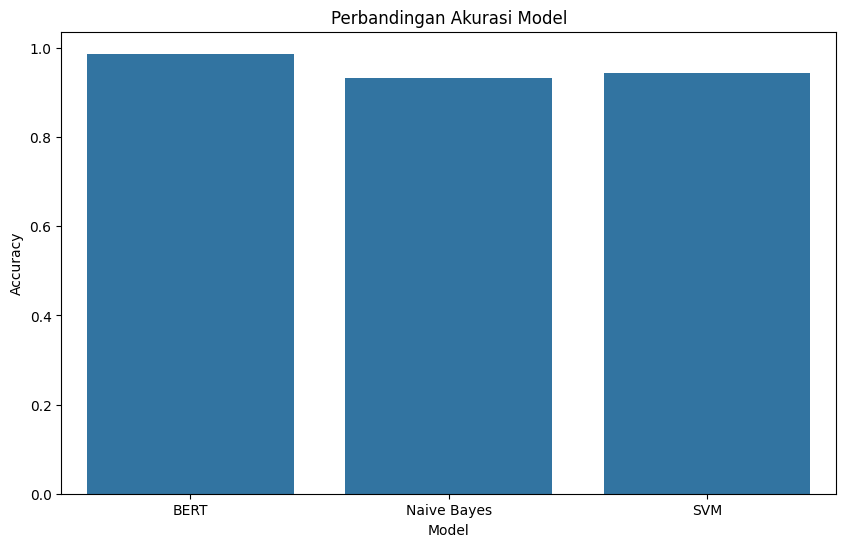

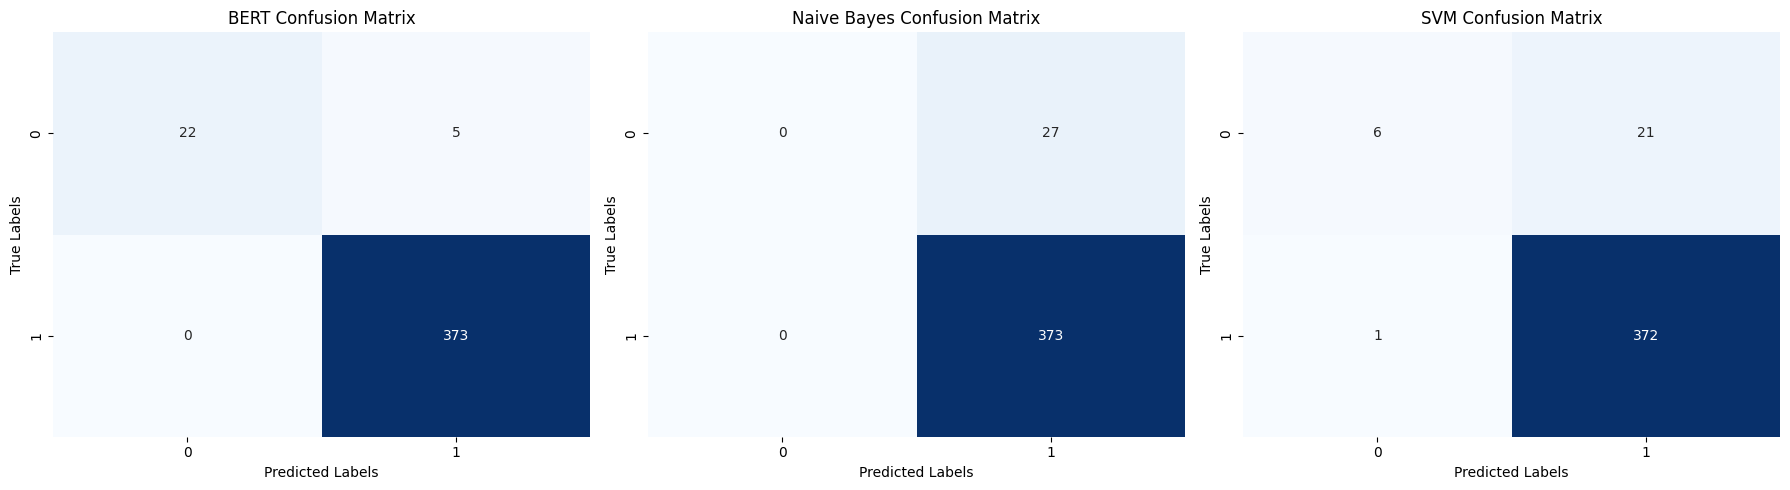

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

# === Model Evaluation === #
# Set model to evaluation mode and gather predictions for validation set
model.eval()
final_predictions = []
with torch.no_grad():
    for batch in val_dataloader:
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)

        # Get model outputs and calculate logits
        outputs = model(batch_input_ids, attention_mask=batch_attention_mask)
        logits = outputs.logits

        # Convert logits to predictions
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        final_predictions.extend(preds)

# Convert final_predictions to numpy array
final_predictions = np.array(final_predictions)

# Convert val_labels to CPU numpy array for comparison
val_true_labels = val_labels.cpu().numpy()

# === Accuracy Comparison DataFrame ===
models_comparison = pd.DataFrame({
    'Model': ['BERT', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(val_true_labels, final_predictions),  # BERT accuracy
        accuracy_score(y_test, nb_predictions),              # Naive Bayes accuracy
        accuracy_score(y_test, svm_predictions)              # SVM accuracy
    ]
})

print("\n=== Perbandingan Model ===")
print(models_comparison)

# === Accuracy Bar Plot ===
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=models_comparison)
plt.title('Perbandingan Akurasi Model')
plt.savefig('model_comparison.png')
plt.show()

# === Heatmap: Confusion Matrix for Each Model ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['BERT', 'Naive Bayes', 'SVM']
predictions = [final_predictions, nb_predictions, svm_predictions]

for i, (model_name, preds) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(val_true_labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Labels")
    axes[i].set_ylabel("True Labels")

plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.png")
plt.show()


**Analisis Aspek Game**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


<Figure size 1500x800 with 0 Axes>

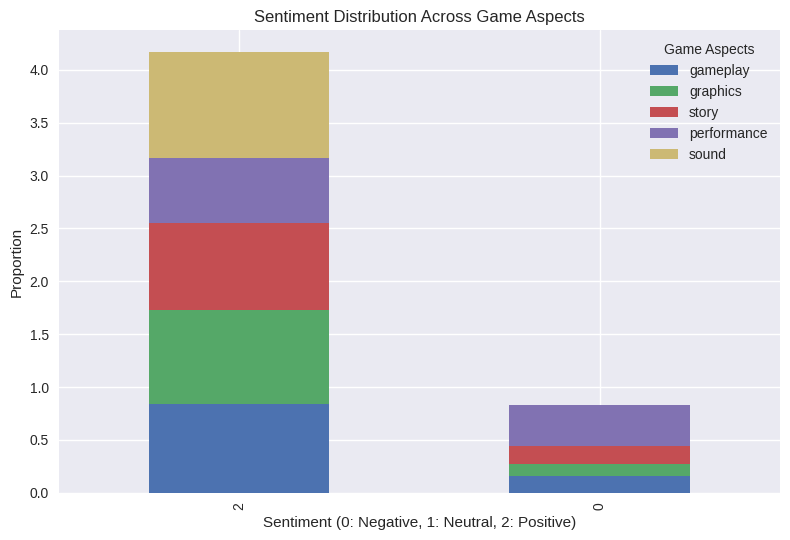

In [ ]:
# === CELL 9: Analisis Aspek Game === #
from wordcloud import WordCloud
from collections import Counter
import spacy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load spaCy model
!pip install spacy
!python -m spacy download en_core_web_sm
import en_core_web_sm
nlp = en_core_web_sm.load()

# Define game aspects and their related keywords
game_aspects = {
    'gameplay': ['combat', 'mechanics', 'controls', 'difficulty', 'boss', 'fights', 'battle'],
    'graphics': ['visual', 'graphics', 'animation', 'design', 'art', 'beautiful', 'stunning'],
    'story': ['story', 'plot', 'narrative', 'lore', 'character', 'dialogue', 'quest'],
    'performance': ['fps', 'performance', 'optimization', 'lag', 'crash', 'bug', 'loading'],
    'sound': ['music', 'sound', 'audio', 'soundtrack', 'voice', 'effects', 'score']
}

def analyze_aspect_sentiment(text, aspect_keywords):
    """Analyze sentiment for specific aspect based on keyword presence"""
    doc = nlp(text.lower())
    for token in doc:
        if token.text in aspect_keywords:
            return True
    return False

# Create aspect columns
for aspect, keywords in game_aspects.items():
    df[f'has_{aspect}'] = df['cleaned_text'].apply(lambda x: analyze_aspect_sentiment(x, keywords))

# Calculate sentiment distribution per aspect
aspect_sentiment = pd.DataFrame()
for aspect in game_aspects.keys():
    aspect_data = df[df[f'has_{aspect}']]['sentiment'].value_counts(normalize=True)
    aspect_sentiment[aspect] = aspect_data

# Visualize aspect sentiment distribution
plt.figure(figsize=(15, 8))
aspect_sentiment.plot(kind='bar', stacked=True)
plt.title('Sentiment Distribution Across Game Aspects')
plt.xlabel('Sentiment (0: Negative, 1: Neutral, 2: Positive)')
plt.ylabel('Proportion')
plt.legend(title='Game Aspects')
plt.tight_layout()
plt.savefig('aspect_sentiment_distribution.png')
plt.show()

**Wordcloud Sentiment**

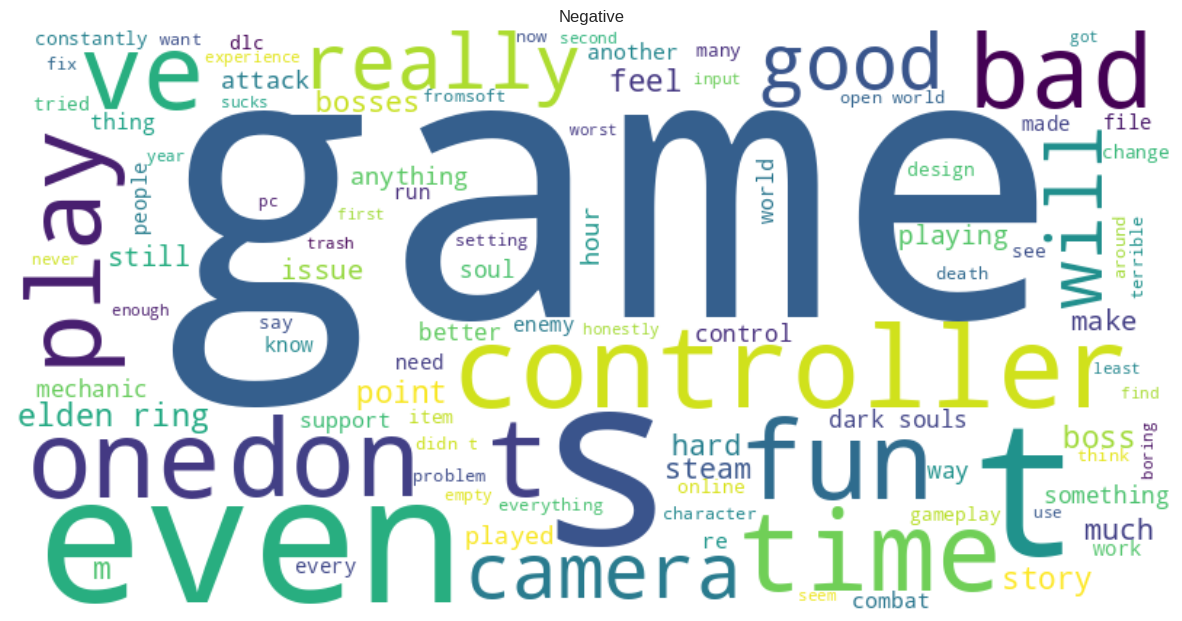

<ipython-input-20-fffc8ce55dd5>:44: UserWarning: No text data for Neutral sentiment. Skipping word cloud generation.
  warnings.warn(f"No text data for {title} sentiment. Skipping word cloud generation.")


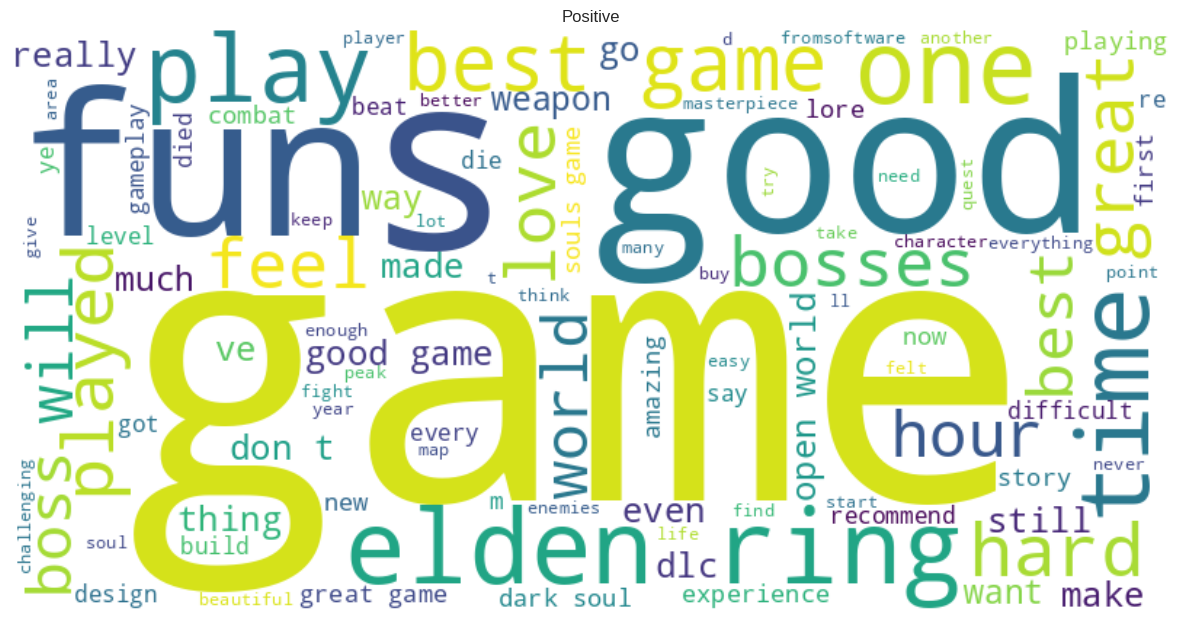

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
from typing import List, Union
import warnings

def generate_wordcloud(
    text_data: Union[pd.Series, List[str]],
    title: str,
    width: int = 800,
    height: int = 400,
    background_color: str = 'white',
    max_words: int = 100,
    output_dir: str = './'
) -> None:
    """
    Generate and save a word cloud visualization from text data.

    Parameters:
    -----------
    text_data : Union[pd.Series, List[str]]
        The text data to generate word cloud from
    title : str
        Title for the word cloud plot and part of filename
    width : int, optional
        Width of the word cloud image (default: 800)
    height : int, optional
        Height of the word cloud image (default: 400)
    background_color : str, optional
        Background color of the word cloud (default: 'white')
    max_words : int, optional
        Maximum number of words to include (default: 100)
    output_dir : str, optional
        Directory to save the word cloud image (default: current directory)

    Returns:
    --------
    None
        Displays the word cloud and saves it as PNG file
    """
    try:
        # Check if text_data is empty
        if len(text_data) == 0:
            warnings.warn(f"No text data for {title} sentiment. Skipping word cloud generation.")
            return

        # Convert text_data to string if it's a pandas Series
        if isinstance(text_data, pd.Series):
            text_data = ' '.join(text_data.astype(str))
        elif isinstance(text_data, list):
            text_data = ' '.join(map(str, text_data))

        # Generate word cloud
        wordcloud = WordCloud(
            width=width,
            height=height,
            background_color=background_color,
            max_words=max_words
        ).generate(text_data)

        # Create and save visualization
        plt.figure(figsize=(15, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(title)

        # Save figure with proper error handling
        try:
            filename = f'{output_dir}/wordcloud_{title.lower()}.png'
            plt.savefig(filename, bbox_inches='tight', dpi=300)
        except Exception as e:
            warnings.warn(f"Failed to save word cloud image: {str(e)}")

        plt.show()
        plt.close()  # Clean up memory

    except Exception as e:
        warnings.warn(f"Error generating word cloud for {title}: {str(e)}")

def generate_sentiment_wordclouds(
    df: pd.DataFrame,
    text_column: str = 'cleaned_text',
    sentiment_column: str = 'sentiment',
    sentiment_labels: List[str] = ['Negative', 'Neutral', 'Positive']
) -> None:
    """
    Generate word clouds for each sentiment category in the dataset.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing text and sentiment data
    text_column : str, optional
        Name of the column containing text data (default: 'cleaned_text')
    sentiment_column : str, optional
        Name of the column containing sentiment values (default: 'sentiment')
    sentiment_labels : List[str], optional
        Labels for each sentiment category (default: ['Negative', 'Neutral', 'Positive'])

    Returns:
    --------
    None
        Generates and displays word clouds for each sentiment
    """
    try:
        # Validate input data
        if text_column not in df.columns:
            raise ValueError(f"Text column '{text_column}' not found in DataFrame")
        if sentiment_column not in df.columns:
            raise ValueError(f"Sentiment column '{sentiment_column}' not found in DataFrame")

        # Generate word cloud for each sentiment
        for sentiment, label in enumerate(sentiment_labels):
            text_data = df[df[sentiment_column] == sentiment][text_column]
            generate_wordcloud(text_data, label)

    except Exception as e:
        warnings.warn(f"Error in generate_sentiment_wordclouds: {str(e)}")

# Example usage:
if __name__ == "__main__":
    # Generate for each sentiment
    generate_sentiment_wordclouds(df)

**Aspect Co-occurence Analysis**

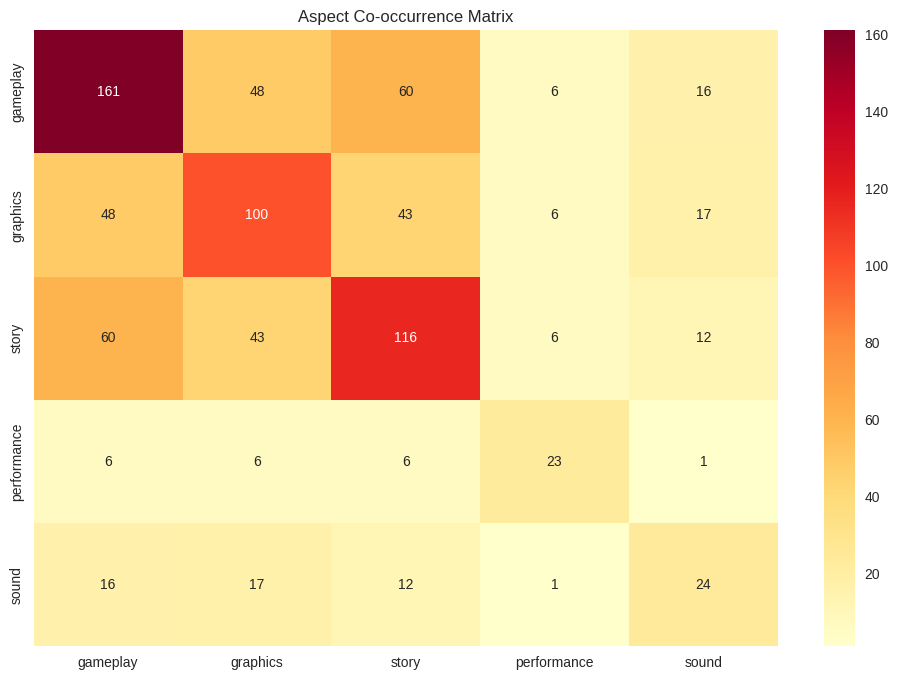

In [ ]:
# === CELL 11: Aspect Co-occurrence Analysis === #
# Create co-occurrence matrix
aspect_matrix = pd.DataFrame()
for aspect1 in game_aspects.keys():
    for aspect2 in game_aspects.keys():
        co_occurrence = len(df[df[f'has_{aspect1}'] & df[f'has_{aspect2}']])
        aspect_matrix.loc[aspect1, aspect2] = co_occurrence

# Ensure aspect_matrix contains integers before plotting
aspect_matrix = aspect_matrix.astype(int) # Convert values to integers

# Visualize co-occurrence heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(aspect_matrix, annot=True, fmt='d', cmap='YlOrRd') # fmt='d' is now appropriate
plt.title('Aspect Co-occurrence Matrix')
plt.savefig('aspect_cooccurrence.png')
plt.show()

**Analisis Temporal**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
from typing import Tuple, Optional

def prepare_temporal_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Processes and prepares data for temporal analysis.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing raw review data with columns like 'month', 'sentiment', 'period'.

    Returns:
    --------
    pd.DataFrame
        Processed DataFrame ready for plotting and analysis.
    """
    # Ensure month column is categorical and ordered from Jan to Dec
    df['month'] = pd.Categorical(df['month'], categories=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ], ordered=True)

    # Group by 'month' and 'period' and calculate mean sentiment and aspect ratings
    df_processed = df.groupby(['month', 'period']).agg({
        'sentiment': 'mean',
        'gameplay': 'mean',
        'graphics': 'mean',
        'story': 'mean',
        'difficulty': 'mean'
    }).reset_index()

    return df_processed

def plot_temporal_analysis(
    df: pd.DataFrame,
    save_path: str = 'Temporal_Sentiment_Trend',
    file_format: str = 'png',
    dpi: int = 300,
    fig_size: Tuple[int, int] = (15, 15),
    style: str = 'seaborn'
) -> None:
    """
    Create comprehensive temporal analysis visualizations with flexible output format.

    Parameters:
    -----------
    df : pd.DataFrame
        Processed DataFrame containing temporal data
    save_path : str
        Base path for saving the visualization (without extension)
    file_format : str
        Output format ('png', 'pdf', 'svg', 'jpg')
    dpi : int
        Resolution for raster formats (png, jpg)
    fig_size : tuple
        Figure size in inches (width, height)
    style : str
        Matplotlib style to use
    """
    # Validate file format
    valid_formats = ['png', 'pdf', 'svg', 'jpg']
    if file_format.lower() not in valid_formats:
        warnings.warn(f"Invalid format. Using PNG. Valid formats are: {', '.join(valid_formats)}")
        file_format = 'png'

    # Set style
    plt.style.use(style)

    # Create figure with specified size
    fig = plt.figure(figsize=fig_size)

    # 1. Sentiment Trends with Period Highlights
    ax1 = plt.subplot(3, 1, 1)
    monthly_stats = df.groupby('month').agg({
        'sentiment': ['mean', 'std', 'count']
    }).droplevel(0, axis=1)

    x = range(len(monthly_stats))

    # Enhanced plot styling
    plt.plot(x, monthly_stats['mean'],
             marker='o',
             color='#1f77b4',  # More vibrant blue
             linewidth=2,
             markersize=8,
             label='Average Sentiment')

    plt.fill_between(x,
                     monthly_stats['mean'] - monthly_stats['std'],
                     monthly_stats['mean'] + monthly_stats['std'],
                     alpha=0.2,
                     color='#1f77b4',
                     label='±1 SD')

    # Enhanced period highlights
    period_colors = {
        'Q1 2024': '#90EE90',  # Light green
        'Q2 2024': '#FFFFE0',  # Light yellow
        'Q3 2024': '#ADD8E6'   # Light blue
    }

    for period in df['period'].unique():
        period_data = df[df['period'] == period]
        period_range = period_data['month'].unique()
        start_idx = np.where(monthly_stats.index == period_range[0])[0][0]
        end_idx = np.where(monthly_stats.index == period_range[-1])[0][0]
        plt.axvspan(start_idx-0.5, end_idx+0.5,
                   color=period_colors[period],
                   alpha=0.3,
                   label=period)

    plt.title('Elden Ring Review Sentiment Trends (Jan 2024 - Sep 2024)',
             fontsize=14,
             pad=20)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Sentiment', fontsize=12)
    plt.xticks(x, monthly_stats.index.astype(str), rotation=45)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=10)

    # 2. Review Volume by Period
    ax2 = plt.subplot(3, 1, 2)
    period_counts = df.groupby(['period', 'month'])['sentiment'].count().unstack()
    period_counts.plot(kind='bar',
                      stacked=True,
                      ax=ax2,
                      colormap='viridis')
    plt.title('Monthly Review Volume by Period (2024)',
             fontsize=14,
             pad=20)
    plt.xlabel('Period', fontsize=12)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(title='Month',
              bbox_to_anchor=(1.05, 1),
              fontsize=10)

    # 3. Aspect Analysis Over Time
    ax3 = plt.subplot(3, 1, 3)
    aspect_columns = ['gameplay', 'graphics', 'story', 'difficulty']
    if all(col in df.columns for col in aspect_columns):
        aspect_data = df.groupby('period')[aspect_columns].mean()
        aspect_data.plot(kind='bar',
                        ax=ax3,
                        colormap='Set3',
                        width=0.8)
        plt.title('Average Aspect Ratings by Period (2024)',
                fontsize=14,
                pad=20)
        plt.xlabel('Period', fontsize=12)
        plt.ylabel('Average Rating', fontsize=12)
        plt.legend(title='Aspects',
                  bbox_to_anchor=(1.05, 1),
                  fontsize=10)
    else:
        plt.text(0.5, 0.5,
                'Aspect data not available',
                ha='center',
                fontsize=12)

    # Adjust layout and save
    plt.tight_layout()

    # Save with specified format and settings
    full_path = f"{save_path}.{file_format.lower()}"
    if file_format.lower() in ['png', 'jpg']:
        plt.savefig(full_path,
                    dpi=dpi,
                    bbox_inches='tight',
                    format=file_format.lower())
    else:
        plt.savefig(full_path,
                    bbox_inches='tight',
                    format=file_format.lower())

    print(f"Visualization saved as {full_path}")
    plt.close()

# Main function to execute the process
def main(df: pd.DataFrame,
         output_format: str = 'png',
         output_name: str = 'Temporal_Analysis') -> None:
    """
    Main function to run temporal analysis with specified output format.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame with review data
    output_format : str
        Desired output format ('png', 'pdf', 'svg', 'jpg')
    output_name : str
        Base name for output files (without extension)
    """
    try:
        # Prepare data
        df_processed = prepare_temporal_data(df)

        # Create visualizations with specified format
        plot_temporal_analysis(
            df_processed,
            save_path=output_name,
            file_format=output_format,
            dpi=300 if output_format.lower() in ['png', 'jpg'] else None
        )

    except Exception as e:
        print(f"Error in temporal analysis: {str(e)}")
        raise

# Example usage
if __name__ == "__main__":
    # Ensure df is defined here, replace it with actual data loading as needed
    df = pd.DataFrame({
        'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
        'sentiment': np.random.uniform(-1, 1, 9),
        'period': ['Q1 2024', 'Q1 2024', 'Q1 2024', 'Q2 2024', 'Q2 2024', 'Q2 2024', 'Q3 2024', 'Q3 2024', 'Q3 2024'],
        'gameplay': np.random.uniform(1, 5, 9),
        'graphics': np.random.uniform(1, 5, 9),
        'story': np.random.uniform(1, 5, 9),
        'difficulty': np.random.uniform(1, 5, 9)
    })
    main(df, output_format='png')


<ipython-input-21-ae4ae4d86bd0>:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_processed = df.groupby(['month', 'period']).agg({
<ipython-input-21-ae4ae4d86bd0>:71: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(style)
<ipython-input-21-ae4ae4d86bd0>:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_stats = df.groupby('month').agg({
<ipython-input-21-ae4a

Visualization saved as Temporal_Analysis.png


<ipython-input-10-87c0c20f12ff>:116: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


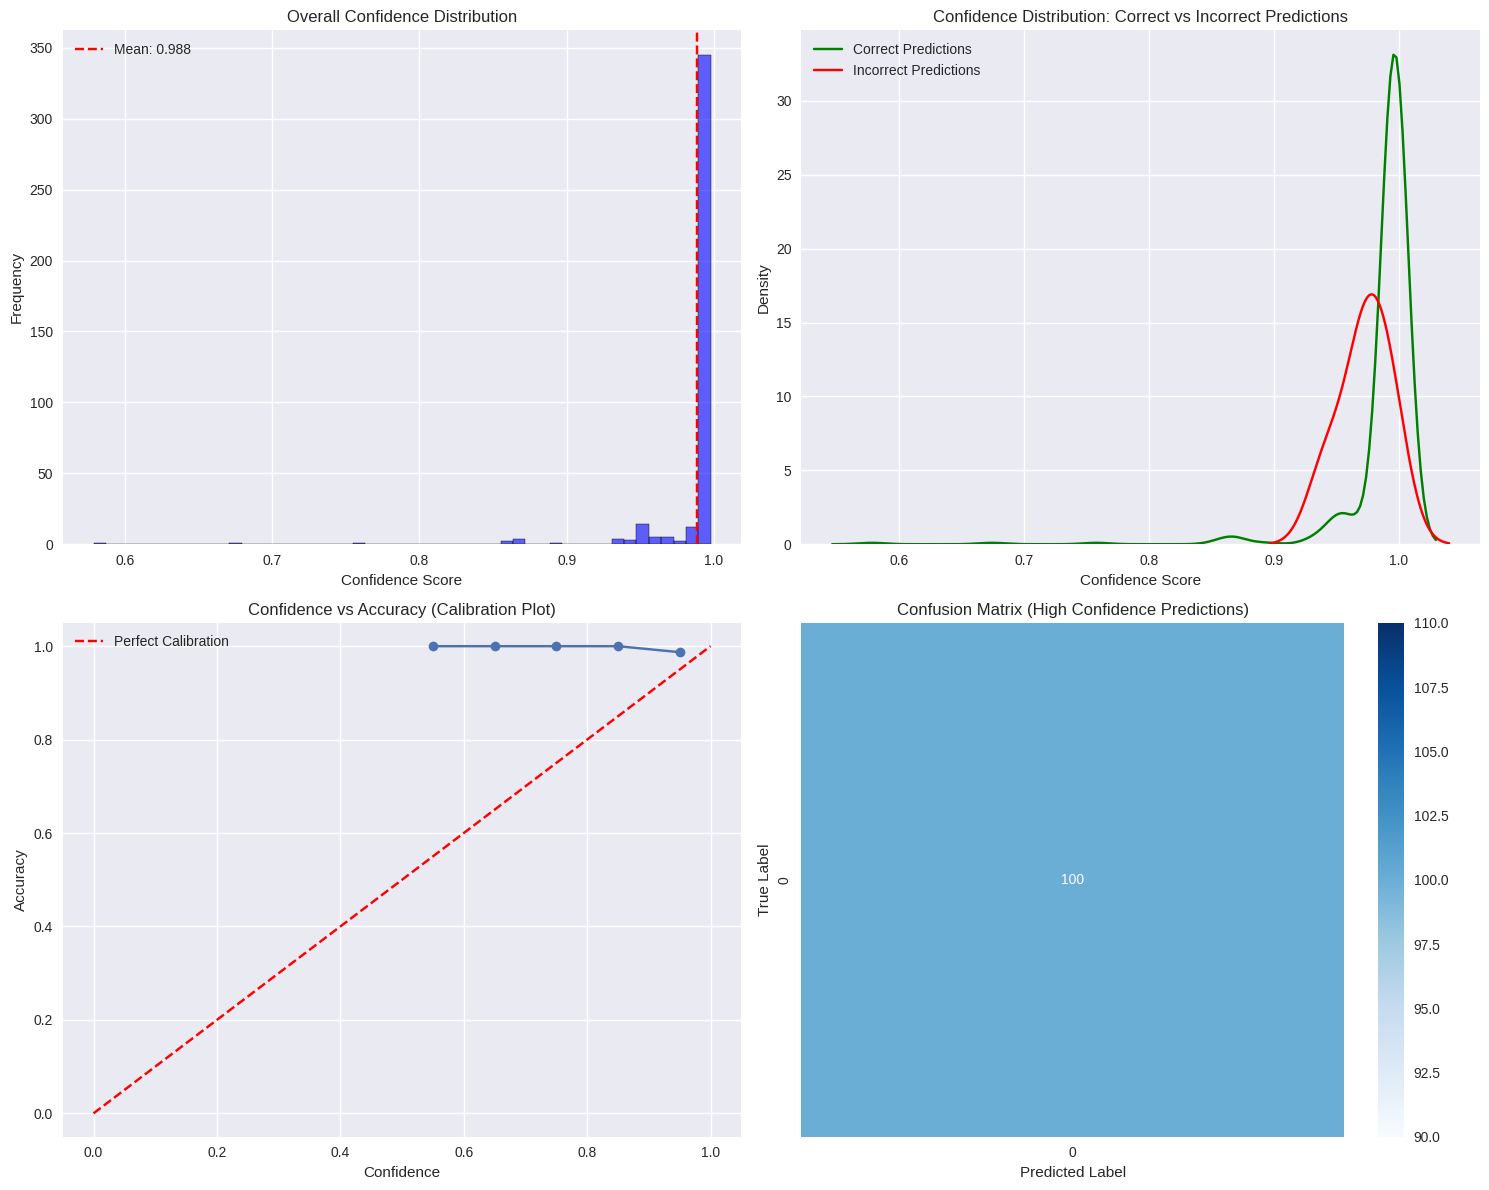

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
from scipy import stats

class AdvancedMetricsAnalyzer:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()  # Ensure model is in evaluation mode

    def calculate_confidence_scores(
        self,
        inputs: Dict[str, torch.Tensor]
    ) -> Tuple[np.ndarray, np.ndarray]:
        try:
            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=1)
                confidence, predictions = torch.max(probs, dim=1)
                return confidence.cpu().numpy(), predictions.cpu().numpy()
        except Exception as e:
            print(f"Error in confidence calculation: {str(e)}")
            raise

    def analyze_confidence_distribution(
        self,
        confidence_scores: np.ndarray,
        predictions: np.ndarray,
        true_labels: np.ndarray
    ) -> Dict[str, float]:
        correct_predictions = predictions == true_labels
        correct_confidences = confidence_scores[correct_predictions]
        incorrect_confidences = confidence_scores[~correct_predictions]

        stats_dict = {
            'mean_confidence': np.mean(confidence_scores),
            'median_confidence': np.median(confidence_scores),
            'std_confidence': np.std(confidence_scores),
            'mean_correct_confidence': np.mean(correct_confidences),
            'mean_incorrect_confidence': np.mean(incorrect_confidences),
            'confidence_accuracy_correlation': np.corrcoef(confidence_scores, correct_predictions.astype(float))[0,1]
        }

        return stats_dict

    def plot_confidence_analysis(
        self,
        confidence_scores: np.ndarray,
        predictions: np.ndarray,
        true_labels: np.ndarray,
        save_path: str = 'advanced_metrics_analysis.png'
    ) -> None:

        correct_predictions = predictions == true_labels
        correct_confidences = confidence_scores[correct_predictions]
        incorrect_confidences = confidence_scores[~correct_predictions]

        plt.style.use('seaborn')
        fig = plt.figure(figsize=(15, 12))

        # 1. Overall Confidence Distribution
        ax1 = plt.subplot(2, 2, 1)
        sns.histplot(confidence_scores, bins=50, color='blue', alpha=0.6)
        plt.axvline(np.mean(confidence_scores), color='red', linestyle='--',
                   label=f'Mean: {np.mean(confidence_scores):.3f}')
        plt.title('Overall Confidence Distribution')
        plt.xlabel('Confidence Score')
        plt.ylabel('Frequency')
        plt.legend()

        # 2. Correct vs Incorrect Predictions
        ax2 = plt.subplot(2, 2, 2)
        sns.kdeplot(data=correct_confidences, label='Correct Predictions', color='green')
        sns.kdeplot(data=incorrect_confidences, label='Incorrect Predictions', color='red')
        plt.title('Confidence Distribution: Correct vs Incorrect Predictions')
        plt.xlabel('Confidence Score')
        plt.ylabel('Density')
        plt.legend()

        # 3. Confidence vs Accuracy
        ax3 = plt.subplot(2, 2, 3)
        confidence_bins = np.linspace(0, 1, 11)
        bin_indices = np.digitize(confidence_scores, confidence_bins) - 1
        bin_accuracies = [np.mean(correct_predictions[bin_indices == i])
                         for i in range(len(confidence_bins)-1)]
        bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2
        plt.plot(bin_centers, bin_accuracies, marker='o')
        plt.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
        plt.title('Confidence vs Accuracy (Calibration Plot)')
        plt.xlabel('Confidence')
        plt.ylabel('Accuracy')
        plt.legend()

        # 4. Confusion Matrix for High Confidence Predictions
        ax4 = plt.subplot(2, 2, 4)
        high_confidence_mask = confidence_scores > np.percentile(confidence_scores, 75)
        conf_matrix = confusion_matrix(true_labels[high_confidence_mask],
                                     predictions[high_confidence_mask])
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix (High Confidence Predictions)')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def print_confidence_statistics(
        self,
        stats_dict: Dict[str, float],
        confidence_scores: np.ndarray,
        predictions: np.ndarray,
        true_labels: np.ndarray
    ) -> None:

        print("\n=== Confidence Analysis Statistics ===")
        print(f"\nOverall Statistics:")
        print(f"Mean Confidence: {stats_dict['mean_confidence']:.3f}")
        print(f"Median Confidence: {stats_dict['median_confidence']:.3f}")
        print(f"Confidence Standard Deviation: {stats_dict['std_confidence']:.3f}")

        print(f"\nAccuracy Analysis:")
        print(f"Mean Confidence (Correct Predictions): {stats_dict['mean_correct_confidence']:.3f}")
        print(f"Mean Confidence (Incorrect Predictions): {stats_dict['mean_incorrect_confidence']:.3f}")
        print(f"Confidence-Accuracy Correlation: {stats_dict['confidence_accuracy_correlation']:.3f}")

        # Calculate additional metrics for high confidence predictions
        high_conf_threshold = np.percentile(confidence_scores, 75)
        high_conf_mask = confidence_scores > high_conf_threshold
        high_conf_accuracy = np.mean(predictions[high_conf_mask] == true_labels[high_conf_mask])

        print(f"\nHigh Confidence Analysis (Top 25% Confidence):")
        print(f"Threshold: {high_conf_threshold:.3f}")
        print(f"Accuracy: {high_conf_accuracy:.3f}")

        # Print classification report for high confidence predictions
        print("\nClassification Report (High Confidence Predictions):")
        print(classification_report(true_labels[high_conf_mask], predictions[high_conf_mask]))

def main(model, val_inputs, val_masks, val_labels, device):

    try:
        # Initialize analyzer
        analyzer = AdvancedMetricsAnalyzer(model, device)

        # Calculate confidence scores and predictions
        inputs = {
            'input_ids': val_inputs.to(device),
            'attention_mask': val_masks.to(device)
        }
        confidence_scores, predictions = analyzer.calculate_confidence_scores(inputs)

        # Analyze distributions
        stats_dict = analyzer.analyze_confidence_distribution(
            confidence_scores,
            predictions,
            val_labels.cpu().numpy()
        )

        # Create visualizations
        analyzer.plot_confidence_analysis(
            confidence_scores,
            predictions,
            val_labels.cpu().numpy()
        )

        # Print statistics
        analyzer.print_confidence_statistics(
            stats_dict,
            confidence_scores,
            predictions,
            val_labels.cpu().numpy()
        )

    except Exception as e:
        print(f"Error in advanced metrics analysis: {str(e)}")
        raise

# Run the analysis
if __name__ == "__main__":
    main(model, val_inputs, val_masks, val_labels, device)

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

def get_confused_cases(true_labels, predictions, texts, logits, n=10):
    """
    Identify cases where the model made mistakes with highest confidence.

    Parameters:
    -----------
    true_labels : array-like
        Ground truth labels
    predictions : array-like
        Model predictions
    texts : array-like
        Input texts corresponding to the predictions
    logits : torch.Tensor or numpy.ndarray
        Model output logits
    n : int
        Number of confused cases to return

    Returns:
    --------
    pd.DataFrame
        DataFrame containing the confused cases with their true labels,
        predicted labels, and confidence scores
    """
    # Convert all inputs to numpy arrays and ensure they have the same length
    true_labels = np.array(true_labels)
    predictions = np.array(predictions)
    texts = np.array(texts)
    logits = np.array(logits)

    # Get the minimum length among all inputs
    min_length = min(len(true_labels), len(predictions), len(texts), len(logits))

    # Trim all arrays to the minimum length
    true_labels = true_labels[:min_length]
    predictions = predictions[:min_length]
    texts = texts[:min_length]
    logits = logits[:min_length]

    # Print debug information
    print(f"Array shapes after alignment:")
    print(f"true_labels shape: {true_labels.shape}")
    print(f"predictions shape: {predictions.shape}")
    print(f"texts shape: {texts.shape}")
    print(f"logits shape: {logits.shape}")

    # Convert logits to probabilities
    if isinstance(logits, torch.Tensor):
        probabilities = F.softmax(logits, dim=1).cpu().numpy()
    else:
        probabilities = F.softmax(torch.tensor(logits), dim=1).numpy()

    # Get confidence scores (probability of predicted class)
    confidence_scores = np.max(probabilities, axis=1)

    # Find indices where predictions were wrong
    incorrect_idx = np.where(true_labels != predictions)[0]

    if len(incorrect_idx) == 0:
        print("No incorrect predictions found!")
        return pd.DataFrame({
            'Text': [],
            'True': [],
            'Predicted': [],
            'Confidence': []
        })

    # Get confidence scores for incorrect predictions
    confidence_incorrect = confidence_scores[incorrect_idx]

    # Sort by confidence (highest first)
    sorted_idx = incorrect_idx[np.argsort(-confidence_incorrect)]

    # Ensure we don't try to get more examples than we have
    n = min(n, len(sorted_idx))

    # Create DataFrame of confused cases
    confused_cases = pd.DataFrame({
        'Text': texts[sorted_idx[:n]],
        'True': true_labels[sorted_idx[:n]],
        'Predicted': predictions[sorted_idx[:n]],
        'Confidence': confidence_scores[sorted_idx[:n]]
    })

    return confused_cases

# Example usage with batch handling:
def analyze_validation_results(model, val_loader, device):
    """
    Analyze validation results across all batches.

    Parameters:
    -----------
    model : torch.nn.Module
        The trained model
    val_loader : torch.utils.data.DataLoader
        Validation data loader
    device : torch.device
        Device to run the model on

    Returns:
    --------
    pd.DataFrame
        DataFrame containing the confused cases
    """
    all_true_labels = []
    all_predictions = []
    all_texts = []
    all_logits = []

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            # Assuming batch contains input_ids, attention_mask, labels, and texts
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()
            texts = batch['texts']  # Assuming you included texts in your dataset

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.cpu().numpy()
            predictions = np.argmax(logits, axis=1)

            all_true_labels.extend(labels)
            all_predictions.extend(predictions)
            all_texts.extend(texts)
            all_logits.extend(logits)

    # Convert lists to arrays
    all_true_labels = np.array(all_true_labels)
    all_predictions = np.array(all_predictions)
    all_texts = np.array(all_texts)
    all_logits = np.array(all_logits)

    return get_confused_cases(
        true_labels=all_true_labels,
        predictions=all_predictions,
        texts=all_texts,
        logits=all_logits
    )

# For your current case, you can use:
# First, ensure all arrays are the same length
min_length = min(len(val_true_labels), len(final_predictions), len(val_texts))
confused_cases = get_confused_cases(
    true_labels=val_true_labels[:min_length],
    predictions=final_predictions[:min_length],
    texts=val_texts[:min_length],
    logits=outputs.logits.detach().cpu().numpy()[:min_length]
)

print("\n=== Most Confused Cases ===")
print(confused_cases)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_review_patterns(df):
    """
    Analyze review patterns including length characteristics, content patterns,
    and influencing factors.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing review data with columns:
        - review_text: text of the review
        - sentiment: sentiment label (0: negative, 1: neutral, 2: positive)
        - playtime_hours: hours played
        - aspects: list of game aspects mentioned
        - technical_issues: boolean or list of technical issues
        - gameplay_elements: list of gameplay elements mentioned

    Returns:
    --------
    dict
        Dictionary containing analysis results
    """
    results = {}

    # 1. Karakteristik Panjang Ulasan
    df['word_count'] = df['review_text'].str.split().str.len()

    length_stats = {
        'positive_length': df[df['sentiment'] == 2]['word_count'].mean(),
        'negative_length': df[df['sentiment'] == 0]['word_count'].mean(),
        'playtime_length_correlation': stats.pearsonr(
            df['playtime_hours'],
            df['word_count']
        )[0]
    }
    results['length_characteristics'] = length_stats

    # 2. Pola Konten Ulasan
    content_patterns = {
        'multiple_aspects_positive': len(df[
            (df['sentiment'] == 2) &
            (df['aspects'].str.len() > 1)
        ]) / len(df[df['sentiment'] == 2]) * 100,

        'single_aspect_negative': len(df[
            (df['sentiment'] == 0) &
            (df['aspects'].str.len() == 1)
        ]) / len(df[df['sentiment'] == 0]) * 100,

        'comparison_percentage': len(df[df['review_text'].str.contains(
            'like|similar|compared to|better than|worse than',
            case=False,
            regex=True
        )]) / len(df) * 100
    }
    results['content_patterns'] = content_patterns

    # 3. Pengaruh Waktu Bermain
    playtime_patterns = {
        'difficulty_low_playtime': len(df[
            (df['playtime_hours'] < 10) &
            (df['gameplay_elements'].str.contains('difficulty', case=False))
        ]) / len(df[df['playtime_hours'] < 10]) * 100,

        'endgame_high_playtime': len(df[
            (df['playtime_hours'] > 50) &
            (df['gameplay_elements'].str.contains('endgame', case=False))
        ]) / len(df[df['playtime_hours'] > 50]) * 100,

        'playtime_sentiment_correlation': stats.pearsonr(
            df['playtime_hours'],
            df['sentiment']
        )[0]
    }
    results['playtime_patterns'] = playtime_patterns

    # 4. Faktor-faktor yang Mempengaruhi
    influence_factors = {
        'technical_factors': {
            'update_sentiment_change': len(df[
                df['review_text'].str.contains('update|patch', case=False)
            ]) / len(df) * 100,
            'recurring_issues': len(df[
                (df['sentiment'] == 0) &
                df['technical_issues']
            ]) / len(df[df['sentiment'] == 0]) * 100,
            'performance_issues': len(df[
                (df['sentiment'] == 0) &
                df['review_text'].str.contains('lag|fps|crash|performance', case=False)
            ]) / len(df[df['sentiment'] == 0]) * 100
        },
        'gameplay_factors': {
            'difficulty_mentions': len(df[
                df['gameplay_elements'].str.contains('difficulty', case=False)
            ]) / len(df) * 100,
            'combat_mentions': len(df[
                df['gameplay_elements'].str.contains('combat|battle|fighting', case=False)
            ]) / len(df) * 100,
            'exploration_positive': len(df[
                (df['sentiment'] == 2) &
                df['gameplay_elements'].str.contains('exploration|world', case=False)
            ]) / len(df[df['sentiment'] == 2]) * 100
        }
    }
    results['influence_factors'] = influence_factors

    return results

def visualize_review_patterns(results, save_path=None):
    """
    Create visualizations for review pattern analysis results.

    Parameters:
    -----------
    results : dict
        Dictionary containing analysis results
    save_path : str, optional
        Path to save the visualizations
    """
    # Set up the visualization style
    plt.style.use('seaborn')

    # Create a 2x2 subplot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))

    # 1. Review Length by Sentiment
    length_data = [
        results['length_characteristics']['positive_length'],
        results['length_characteristics']['negative_length']
    ]
    ax1.bar(['Positive', 'Negative'], length_data)
    ax1.set_title('Average Review Length by Sentiment')
    ax1.set_ylabel('Number of Words')

    # 2. Content Pattern Distribution
    content_data = [
        results['content_patterns']['multiple_aspects_positive'],
        results['content_patterns']['single_aspect_negative'],
        results['content_patterns']['comparison_percentage']
    ]
    ax2.bar(['Multiple Aspects\n(Positive)', 'Single Aspect\n(Negative)', 'Contains\nComparisons'],
            content_data)
    ax2.set_title('Content Pattern Distribution')
    ax2.set_ylabel('Percentage of Reviews')

    # 3. Technical Factors
    technical_data = results['influence_factors']['technical_factors']
    ax3.bar(technical_data.keys(), technical_data.values())
    ax3.set_title('Technical Factors in Reviews')
    ax3.set_ylabel('Percentage of Reviews')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

    # 4. Gameplay Factors
    gameplay_data = results['influence_factors']['gameplay_factors']
    ax4.bar(gameplay_data.keys(), gameplay_data.values())
    ax4.set_title('Gameplay Factors in Reviews')
    ax4.set_ylabel('Percentage of Reviews')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)

    return fig

# Example usage:
"""
df = pd.DataFrame({
    'review_text': [...],
    'sentiment': [...],
    'playtime_hours': [...],
    'aspects': [...],
    'technical_issues': [...],
    'gameplay_elements': [...]
})

results = analyze_review_patterns(df)
fig = visualize_review_patterns(results, 'review_patterns.png')
"""